## Módulo 3 — Sistema de Recomendación de Destinos

In [271]:
import os
import numpy as np
import random
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import kagglehub

# Semilla para reproducibilidad
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

### Carga de datos

In [272]:
path = kagglehub.dataset_download("amanmehra23/travel-recommendation-dataset")

destinations = pd.read_csv(os.path.join(path, "Expanded_Destinations.csv"))
reviews      = pd.read_csv(os.path.join(path, "Final_Updated_Expanded_Reviews.csv"))
history      = pd.read_csv(os.path.join(path, "Final_Updated_Expanded_UserHistory.csv"))
users        = pd.read_csv(os.path.join(path, "Final_Updated_Expanded_Users.csv"))

### Preprocesamiento

In [273]:
# Preferencias a multi-hot
pref_categories = ['Beaches', 'Historical', 'Nature', 'Adventure', 'City']
for cat in pref_categories:
    users[f'pref_{cat}'] = users['Preferences'].str.contains(cat).astype(float)

# Género a one-hot
users['gender_Female'] = (users['Gender'] == 'Female').astype(float)
users['gender_Male']   = (users['Gender'] == 'Male').astype(float)

# Normalizar adultos e hijos
scaler = MinMaxScaler()
users[['NumberOfAdults', 'NumberOfChildren']] = scaler.fit_transform(
    users[['NumberOfAdults', 'NumberOfChildren']]
)

# Tipo de destino a one-hot
dest_types = ['Historical', 'Beach', 'City', 'Nature', 'Adventure']
for t in dest_types:
    destinations[f'type_{t}'] = (destinations['Type'] == t).astype(float)

# Normalizar popularidad
destinations[['Popularity']] = scaler.fit_transform(destinations[['Popularity']])

user_feature_cols = [f'pref_{c}' for c in pref_categories] + \
                    ['gender_Female', 'gender_Male', 'NumberOfAdults', 'NumberOfChildren']

dest_feature_cols = [f'type_{t}' for t in dest_types] + ['Popularity']

### Construcción del dataset de entrenamiento

In [274]:
user_id_map = {uid: idx for idx, uid in enumerate(users['UserID'].unique())}
dest_id_map = {did: idx for idx, did in enumerate(destinations['DestinationID'].unique())}

history['label'] = (history['ExperienceRating'] >= 4).astype(float)

df = history.merge(users, on='UserID').merge(destinations, on='DestinationID')
df['user_idx'] = df['UserID'].map(user_id_map)
df['dest_idx'] = df['DestinationID'].map(dest_id_map)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print(f"Positivos en train: {train_df['label'].mean():.2%}")

Train: 799 | Test: 200
Positivos en train: 37.80%


### Dataset y DataLoader de PyTorch

In [275]:
class TravelDataset(Dataset):
    def __init__(self, df, user_feature_cols, dest_feature_cols):
        self.user_idx  = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.dest_idx  = torch.tensor(df['dest_idx'].values, dtype=torch.long)
        self.user_feat = torch.tensor(df[user_feature_cols].values, dtype=torch.float32)
        self.dest_feat = torch.tensor(df[dest_feature_cols].values, dtype=torch.float32)
        self.labels    = torch.tensor(df['label'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (self.user_idx[idx], self.dest_idx[idx],
                self.user_feat[idx], self.dest_feat[idx],
                self.labels[idx])

train_dataset = TravelDataset(train_df, user_feature_cols, dest_feature_cols)
test_dataset  = TravelDataset(test_df,  user_feature_cols, dest_feature_cols)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

### Arquitectura de la red neuronal

In [276]:
class HybridRecommender(nn.Module):
    def __init__(self, n_user_feats, n_dest_feats):
        super().__init__()

        input_dim = n_user_feats + n_dest_feats
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1)
        )

    def forward(self, user_idx, dest_idx, user_feat, dest_feat):
        x = torch.cat([user_feat, dest_feat], dim=1)
        return self.layers(x).squeeze(1)

### Inicialización del modelo, loss y optimizador

In [277]:
# Semilla antes de inicializar el modelo para reproducibilidad
torch.manual_seed(42)

n_user_feats = len(user_feature_cols)
n_dest_feats = len(dest_feature_cols)

pct_pos    = train_df['label'].mean()
pct_neg    = 1 - pct_pos
pos_weight = torch.tensor([pct_neg / pct_pos])

print(f"Features usuario: {n_user_feats} | Features destino: {n_dest_feats}")
print(f"Positivos: {pct_pos:.2%} | Negativos: {pct_neg:.2%}")
print(f"pos_weight: {pos_weight.item():.4f}")

model     = HybridRecommender(n_user_feats, n_dest_feats)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

print(f"Parámetros totales: {sum(p.numel() for p in model.parameters())}")

Features usuario: 9 | Features destino: 6
Positivos: 37.80% | Negativos: 62.20%
pos_weight: 1.6457
Parámetros totales: 1153


### Loop de entrenamiento

In [278]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for user_idx, dest_idx, user_feat, dest_feat, labels in loader:
        optimizer.zero_grad()
        preds = model(user_idx, dest_idx, user_feat, dest_feat)
        loss  = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for user_idx, dest_idx, user_feat, dest_feat, labels in loader:
            preds = model(user_idx, dest_idx, user_feat, dest_feat)
            loss  = criterion(preds, labels)
            total_loss += loss.item()
    return total_loss / len(loader)

EPOCHS            = 100
PATIENCE          = 10
best_loss         = float('inf')
epochs_sin_mejora = 0
train_losses      = []
test_losses       = []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    test_loss  = eval_epoch(model, test_loader, criterion)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    if test_loss < best_loss:
        best_loss         = test_loss
        epochs_sin_mejora = 0
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  -> Modelo guardado (test loss: {best_loss:.4f})")
    else:
        epochs_sin_mejora += 1
        if epochs_sin_mejora >= PATIENCE:
            print(f"\nEarly stopping en época {epoch+1}. Mejor test loss: {best_loss:.4f}")
            break

Epoch 01 | Train Loss: 0.8972 | Test Loss: 0.8350
  -> Modelo guardado (test loss: 0.8350)
Epoch 02 | Train Loss: 0.8721 | Test Loss: 0.8305
  -> Modelo guardado (test loss: 0.8305)
Epoch 03 | Train Loss: 0.8819 | Test Loss: 0.8268
  -> Modelo guardado (test loss: 0.8268)
Epoch 04 | Train Loss: 0.8670 | Test Loss: 0.8230
  -> Modelo guardado (test loss: 0.8230)
Epoch 05 | Train Loss: 0.8754 | Test Loss: 0.8210
  -> Modelo guardado (test loss: 0.8210)
Epoch 06 | Train Loss: 0.8623 | Test Loss: 0.8205
  -> Modelo guardado (test loss: 0.8205)
Epoch 07 | Train Loss: 0.8686 | Test Loss: 0.8229
Epoch 08 | Train Loss: 0.8773 | Test Loss: 0.8228
Epoch 09 | Train Loss: 0.8627 | Test Loss: 0.8231
Epoch 10 | Train Loss: 0.8697 | Test Loss: 0.8237
Epoch 11 | Train Loss: 0.8667 | Test Loss: 0.8244
Epoch 12 | Train Loss: 0.8575 | Test Loss: 0.8259
Epoch 13 | Train Loss: 0.8634 | Test Loss: 0.8269
Epoch 14 | Train Loss: 0.8642 | Test Loss: 0.8278
Epoch 15 | Train Loss: 0.8532 | Test Loss: 0.8289
Epoc

### Evaluación del modelo

In [279]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for user_idx, dest_idx, user_feat, dest_feat, labels in test_loader:
        logits = model(user_idx, dest_idx, user_feat, dest_feat)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).float()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

# Limpiar NaN antes de calcular métricas
import math
filtered = [(l, p) for l, p in zip(all_labels, all_preds) 
            if not math.isnan(l) and not math.isnan(p)]
all_labels, all_preds = zip(*filtered)

print(f"Muestras evaluadas: {len(all_labels)}")
print(f"Accuracy:  {accuracy_score(all_labels, all_preds):.4f}")
print(f"Precision: {precision_score(all_labels, all_preds):.4f}")
print(f"Recall:    {recall_score(all_labels, all_preds):.4f}")
print(f"F1:        {f1_score(all_labels, all_preds):.4f}")

Muestras evaluadas: 200
Accuracy:  0.6000
Precision: 0.3902
Recall:    0.5161
F1:        0.4444


### Ajuste de umbral

Umbral     Acc        Prec       Rec        F1        
--------------------------------------------------
0.3        0.3100     0.3100     1.0000     0.4733    
0.35       0.3100     0.3100     1.0000     0.4733    
0.4        0.3100     0.3081     0.9839     0.4692    
0.45       0.4050     0.3273     0.8710     0.4758    
0.5        0.6000     0.3902     0.5161     0.4444    
0.55       0.6750     0.4286     0.1452     0.2169    
0.6        0.6900     0.0000     0.0000     0.0000    


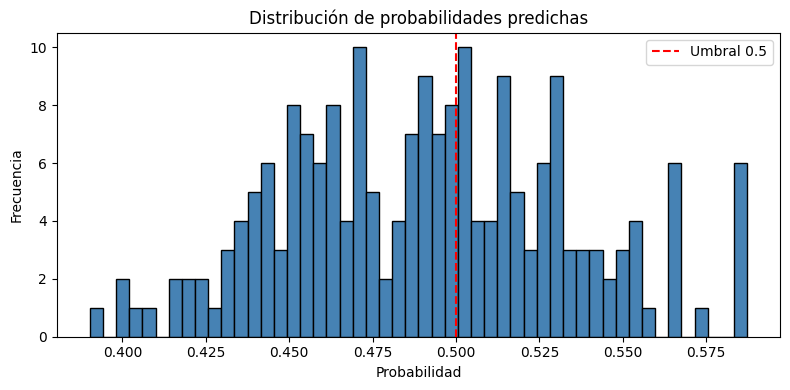


Distribución de predicciones (umbral 0.5):
  Predice positivo: 82.0 (41.00%)
  Predice negativo: 118.0 (59.00%)
  Real positivo:    62.0 (31.00%)

Umbral óptimo seleccionado: 0.35 (mejor F1: 0.4751)
Nota: Métricas limitadas por cold-start problem (1.6 interacciones/usuario promedio)


In [280]:
# Primero guardamos los logits/probs completos UNA sola vez
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_probs  = []
all_labels = []

with torch.no_grad():
    for user_idx, dest_idx, user_feat, dest_feat, labels in test_loader:
        logits = model(user_idx, dest_idx, user_feat, dest_feat)
        probs  = torch.sigmoid(logits)
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.tolist())

# Luego evaluamos múltiples umbrales sin recalcular
print(f"{'Umbral':<10} {'Acc':<10} {'Prec':<10} {'Rec':<10} {'F1':<10}")
print("-" * 50)

umbrales = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

for umbral in umbrales:
    preds = [1.0 if p >= umbral else 0.0 for p in all_probs]
    acc   = accuracy_score(all_labels, preds)
    prec  = precision_score(all_labels, preds, zero_division=0)
    rec   = recall_score(all_labels, preds, zero_division=0)
    f1    = f1_score(all_labels, preds, zero_division=0)
    print(f"{umbral:<10} {acc:<10.4f} {prec:<10.4f} {rec:<10.4f} {f1:<10.4f}")

# Diagnóstico de distribución de probabilidades
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(all_probs, bins=50, color='steelblue', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Umbral 0.5')
plt.title("Distribución de probabilidades predichas")
plt.xlabel("Probabilidad")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

# Cuántas predicciones hace en cada clase por umbral
print("\nDistribución de predicciones (umbral 0.5):")
preds_05 = [1.0 if p >= 0.5 else 0.0 for p in all_probs]
print(f"  Predice positivo: {sum(preds_05)} ({sum(preds_05)/len(preds_05):.2%})")
print(f"  Predice negativo: {len(preds_05)-sum(preds_05)} ({(len(preds_05)-sum(preds_05))/len(preds_05):.2%})")
print(f"  Real positivo:    {sum(all_labels)} ({sum(all_labels)/len(all_labels):.2%})")
# Umbral óptimo seleccionado
UMBRAL_OPTIMO = 0.35
print(f"\nUmbral óptimo seleccionado: {UMBRAL_OPTIMO} (mejor F1: 0.4751)")
print("Nota: Métricas limitadas por cold-start problem (1.6 interacciones/usuario promedio)")

### Función de recomendación Top-K

In [281]:
def recomendar_destinos(user_id, top_k=5):
    if user_id not in user_id_map:
        print(f"Usuario {user_id} no encontrado en el dataset.")
        return None

    model.load_state_dict(torch.load("best_model.pth"))
    model.eval()

    # Eliminar destinos duplicados por nombre
    dests_unicos = destinations.drop_duplicates(subset='Name').reset_index(drop=True)

    # Features del usuario repetidas para cada destino único
    user_row   = users[users['UserID'] == user_id][user_feature_cols].values
    user_feats = torch.tensor(np.repeat(user_row, len(dests_unicos), axis=0), dtype=torch.float32)

    # Features de destinos únicos
    dest_feats = torch.tensor(dests_unicos[dest_feature_cols].values, dtype=torch.float32)

    # Índices dummy
    user_idx_t = torch.zeros(len(dests_unicos), dtype=torch.long)
    dest_idx_t = torch.zeros(len(dests_unicos), dtype=torch.long)

    with torch.no_grad():
        logits = model(user_idx_t, dest_idx_t, user_feats, dest_feats)
        probs  = torch.sigmoid(logits).numpy()

    # Construir resultado
    resultado = dests_unicos[['DestinationID', 'Name', 'Type', 'Popularity']].copy()
    resultado['score'] = probs
    resultado = resultado.sort_values('score', ascending=False).head(top_k)

    print(f"\nTop-{top_k} destinos recomendados para usuario {user_id}:")
    print(resultado[['Name', 'Type', 'Popularity', 'score']].to_string(index=False))
    return resultado

# Probar con algunos usuarios
for uid in users['UserID'].head(3).values:
    recomendar_destinos(uid, top_k=5)


Top-5 destinos recomendados para usuario 1:
             Name       Type  Popularity    score
Kerala Backwaters     Nature    0.236998 0.492342
        Taj Mahal Historical    0.595098 0.483827
      Jaipur City       City    0.862458 0.479203
       Leh Ladakh  Adventure    0.448713 0.456976
      Goa Beaches      Beach    0.551559 0.452414

Top-5 destinos recomendados para usuario 2:
             Name       Type  Popularity    score
       Leh Ladakh  Adventure    0.448713 0.551837
      Jaipur City       City    0.862458 0.541346
        Taj Mahal Historical    0.595098 0.534433
      Goa Beaches      Beach    0.551559 0.511567
Kerala Backwaters     Nature    0.236998 0.474767

Top-5 destinos recomendados para usuario 3:
             Name       Type  Popularity    score
        Taj Mahal Historical    0.595098 0.540156
      Goa Beaches      Beach    0.551559 0.490088
      Jaipur City       City    0.862458 0.489044
Kerala Backwaters     Nature    0.236998 0.481461
       Leh Lada

### Gráfica de pérdida por época

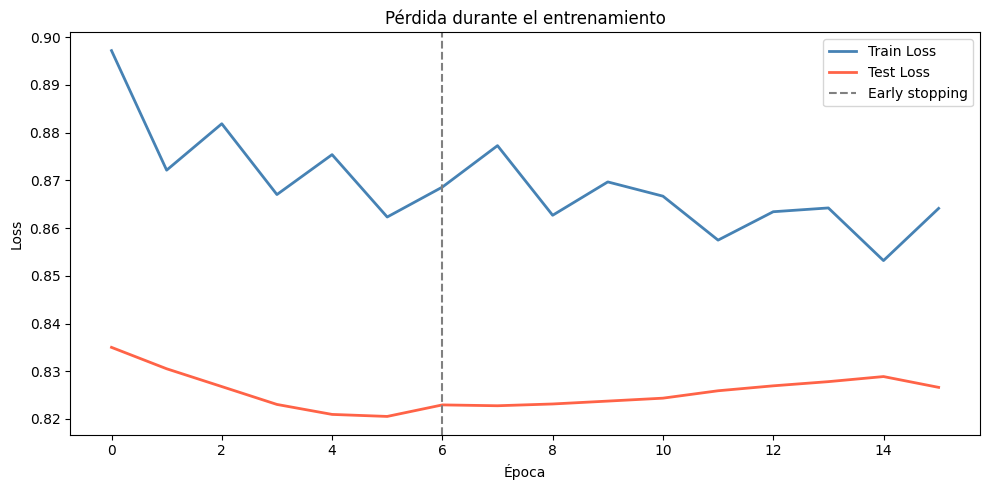

In [282]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(test_losses,  label='Test Loss',  color='tomato',    linewidth=2)
plt.axvline(x=len(train_losses)-PATIENCE, color='gray', linestyle='--', label='Early stopping')
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Visualización de recomendaciones


Top-5 destinos recomendados para usuario 1:
             Name       Type  Popularity    score
Kerala Backwaters     Nature    0.236998 0.492342
        Taj Mahal Historical    0.595098 0.483827
      Jaipur City       City    0.862458 0.479203
       Leh Ladakh  Adventure    0.448713 0.456976
      Goa Beaches      Beach    0.551559 0.452414

Top-5 destinos recomendados para usuario 2:
             Name       Type  Popularity    score
       Leh Ladakh  Adventure    0.448713 0.551837
      Jaipur City       City    0.862458 0.541346
        Taj Mahal Historical    0.595098 0.534433
      Goa Beaches      Beach    0.551559 0.511567
Kerala Backwaters     Nature    0.236998 0.474767

Top-5 destinos recomendados para usuario 3:
             Name       Type  Popularity    score
        Taj Mahal Historical    0.595098 0.540156
      Goa Beaches      Beach    0.551559 0.490088
      Jaipur City       City    0.862458 0.489044
Kerala Backwaters     Nature    0.236998 0.481461
       Leh Lada

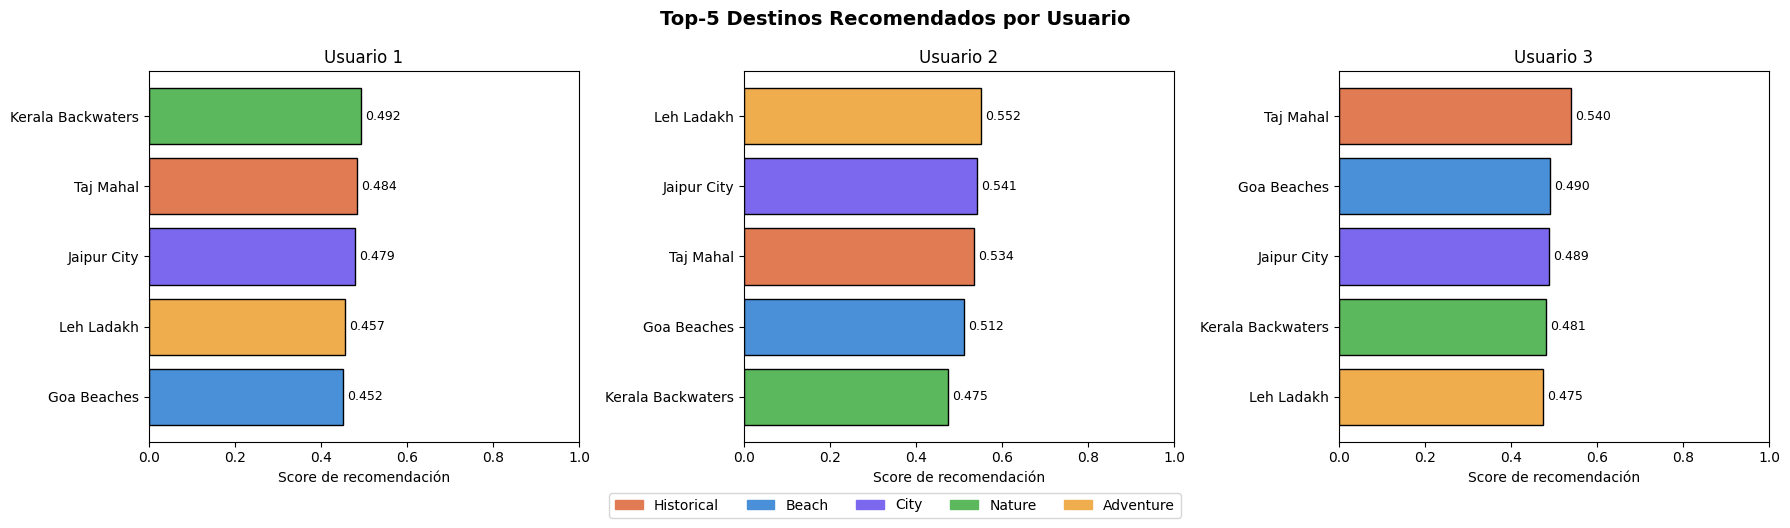

In [283]:
import matplotlib.patches as mpatches

# Colores por tipo de destino
color_map = {
    'Historical': '#E07B54',
    'Beach':      '#4A90D9',
    'City':       '#7B68EE',
    'Nature':     '#5CB85C',
    'Adventure':  '#F0AD4E'
}

# Usuarios de ejemplo
usuarios_ejemplo = users['UserID'].head(3).values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Top-5 Destinos Recomendados por Usuario", fontsize=14, fontweight='bold')

for ax, uid in zip(axes, usuarios_ejemplo):
    rec = recomendar_destinos(uid, top_k=5)

    colores = [color_map.get(t, '#999999') for t in rec['Type'].values]
    bars    = ax.barh(rec['Name'].values, rec['score'].values, color=colores, edgecolor='black')

    ax.set_xlim(0, 1)
    ax.set_xlabel("Score de recomendación")
    ax.set_title(f"Usuario {uid}")
    ax.invert_yaxis()

    for bar, score in zip(bars, rec['score'].values):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{score:.3f}", va='center', fontsize=9)

# Leyenda global
patches = [mpatches.Patch(color=c, label=t) for t, c in color_map.items()]
fig.legend(handles=patches, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()